In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm import tqdm

save_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph_manual")
metadata_dir = save_dir / "metadata"

gauges = gpd.read_parquet(metadata_dir / "gauges.parquet").set_index('site_id')

subs_df = pd.read_parquet(metadata_dir / 'subbasins.parquet', columns=['site_id', 'is_gauge', 'uparea_km2', 'outlet_id'])
subs_df.index = subs_df.index.astype(str)

basin_subbasin_dict = subs_df.groupby('outlet_id').apply(lambda g: g.index.tolist(), include_groups=False).to_dict()

In [3]:
from data import ZarrBasinStore
store_path = Path("/scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched")
store = ZarrBasinStore(store_path)

store.compute_and_store_stats(basins = 'USGS-07374000')

Dask client started. Dashboard at: http://127.0.0.1:8787/status


Basins:   0%|          | 0/1 [00:00<?, ?it/s]/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 11.29 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/dask/array/reductions.py:324: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/dask/array/reductions.py:291: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)
/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/dask/array/reductions.py:324: RuntimeWarni

In [2]:
subs_df['original_comid'] = subs_df.index

# A small % of gauges are dropped if they don't match well.
common_idx = subs_df.index.intersection(gauges.index)
subs_df.loc[common_idx, 'original_comid'] = gauges.loc[common_idx, 'COMID'].astype(str)

subs_df

,is_gauge,uparea_km2,outlet_id,original_comid
site_id,,,,
23021321,False,209.123678,EAUF-A3750050,23021321
23021261,False,213.109547,EAUF-A3750050,23021261
23021244,False,291.030672,EAUF-A3750050,23021244
23021122,False,477.964586,EAUF-A3750050,23021122
23021112,False,394.295017,EAUF-A3750050,23021112
...,...,...,...,...
81003765,False,1613.152478,USGS-15908000,81003765
81001414,False,1473.949940,USGS-15908000,81001414
81001413,False,2751.705206,USGS-15908000,81001413


In [3]:
paths = Path("/nas/cee-ice/data/MERIT-BASINS/v07_to_bugfix").glob("v07_to_bugfix_pfaf1_*.csv")
bugfix_to_v07 = pd.concat([pd.read_csv(p, dtype=str) for p in paths]).set_index('COMID_bugfix')
subs_df = subs_df.merge(bugfix_to_v07, how='left', left_on='original_comid', right_index=True)
subs_df

,is_gauge,uparea_km2,outlet_id,original_comid,COMID_v07
site_id,,,,,
23021321,False,209.123678,EAUF-A3750050,23021321,23020861
23021261,False,213.109547,EAUF-A3750050,23021261,23020837
23021244,False,291.030672,EAUF-A3750050,23021244,23020833
23021122,False,477.964586,EAUF-A3750050,23021122,23020781
23021112,False,394.295017,EAUF-A3750050,23021112,23020778
...,...,...,...,...,...
81003765,False,1613.152478,USGS-15908000,81003765,81003353
81001414,False,1473.949940,USGS-15908000,81001414,81002712
81001413,False,2751.705206,USGS-15908000,81001413,81002593


In [4]:
import xarray as xr

datasets = Path("/nas/cee-ice/data")
m2s_path = datasets/"MERIT-SWORD"/"ms_translate"/"mb_to_sword"
get_m2s_file = lambda pfaf2: m2s_path / f"mb_to_sword_pfaf_{pfaf2}_translate.nc"

subs_df['pfaf2'] = subs_df['original_comid'].astype(int)//int(1E6)

pfaf2_chunks = []
for pfaf2, row in tqdm(subs_df.groupby('pfaf2')):
    m2s_df = xr.open_dataset(get_m2s_file(pfaf2)).to_pandas()
    m2s_df = m2s_df.replace(0, pd.NA).dropna(how='all')
    m2s_df.index = m2s_df.index.astype(str)

    chunk = row.merge(m2s_df, how='inner', left_on='COMID_v07', right_index=True)
    chunk = chunk['sword_1'].rename('sword_id')
    pfaf2_chunks.append(chunk)
    
site2sword = pd.concat(pfaf2_chunks)
subs_df = subs_df.join(site2sword)

subs_df

100%|██████████| 19/19 [00:09<00:00,  2.04it/s]


,is_gauge,uparea_km2,outlet_id,original_comid,COMID_v07,pfaf2,sword_id
site_id,,,,,,,
23021321,False,209.123678,EAUF-A3750050,23021321,23020861,23,NaN
23021261,False,213.109547,EAUF-A3750050,23021261,23020837,23,NaN
23021244,False,291.030672,EAUF-A3750050,23021244,23020833,23,NaN
23021122,False,477.964586,EAUF-A3750050,23021122,23020781,23,NaN
23021112,False,394.295017,EAUF-A3750050,23021112,23020778,23,NaN
...,...,...,...,...,...,...,...
81003765,False,1613.152478,USGS-15908000,81003765,81003353,81,81390400181
81001414,False,1473.949940,USGS-15908000,81001414,81002712,81,81390400271
81001413,False,2751.705206,USGS-15908000,81001413,81002593,81,81390400151


In [6]:
import pyarrow.dataset as ds
import itertools 

all_reaches = subs_df['sword_id'].dropna().to_list()

fields=[
    'reach_id', 'pass_id', 'time','wse', 'wse_u', 'wse_r_u',
    'slope', 'slope_u', 'slope_r_u', 'slope2', 'slope2_u', 'slope2_r_u',
    'width', 'width_u',
    'area_total', 'area_tot_u', 'area_detct', 'area_det_u', 'area_wse',
    'layovr_val', 'node_dist', 'loc_offset', 'xtrk_dist',
    'reach_q', 'reach_q_b', 'dark_frac', 'ice_clim_f', 'partial_f',
    'obs_frac_n', 'xovr_cal_q', 'dry_trop_c', 'wet_trop_c', 'iono_c', 'xovr_cal_c'
]

reach_dir  = datasets / 'hydrocron' / 'reach'
list(reach_dir.glob('*.parquet'))

swot = []
for reach_file in reach_dir.glob('*_hydrocron_reach.parquet'):
    dataset = ds.dataset(reach_file, format="parquet")
    table = dataset.to_table(
        columns=fields,
        filter=(ds.field("reach_id").isin(all_reaches))
    )
    swot.append(table.to_pandas())
    
all_swot = pd.concat(swot)
all_swot = all_swot[all_swot['wse'] != -999999999999.0]
all_swot = all_swot[all_swot['wse_u']<0.2]
all_swot = all_swot[all_swot['reach_q_b'] < 2**18].copy()
all_swot['d_wse'] = all_swot['wse'] - all_swot.groupby('reach_id')['wse'].transform('median')
all_swot['d_width'] = all_swot['width'] - all_swot.groupby('reach_id')['width'].transform('median')

all_swot = all_swot.set_index(['reach_id','time'])

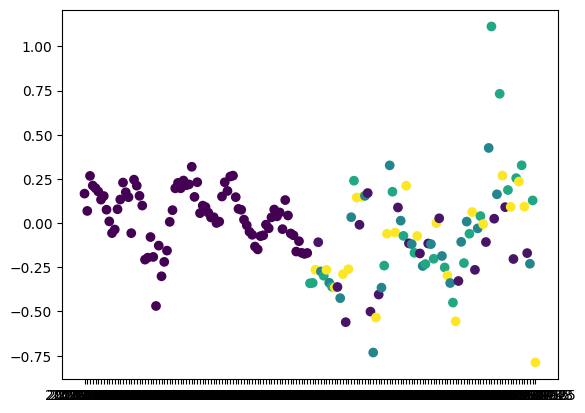

In [28]:
reach_df  = all_swot.loc[82212400141].copy()

import matplotlib.pyplot as plt
plt.scatter(reach_df.index, reach_df['d_wse'], c=reach_df['pass_id'])

In [30]:
def get_best_record(grp):
    return grp.sort_values('wse_u').iloc[0]
    
def get_swot_r(reach_id):
    if np.isnan(reach_id):
        return None
        
    try:
        swot = all_swot.xs(reach_id, level='reach_id')
    except KeyError:
        return None
        
    swot.index = pd.to_datetime(swot.index).tz_localize('UTC')
    # For any duplicated dates, pick the best obs according to uncertainty estimate.
    if any(swot.index.duplicated()):
        swot = swot.groupby(swot.index.name).apply(get_best_record)

    return swot.add_suffix('_river')



BATCH_SIZE = 10000
batches = []
for basin_id, basin_group in subs_df.groupby('outlet_id'):
    basin_subs = basin_subbasin_dict[basin_id]
    n_subs = len(basin_subs)

    for i in range(0, n_subs, BATCH_SIZE):
        batch_subs = basin_subs[i : i + BATCH_SIZE]
        batches.append((basin_id, batch_subs))


for basin_id, batch_subs in tqdm(batches):
    basin_subs = basin_subbasin_dict[basin_id]
    batch_df_list = []
    for subbasin in batch_subs:
        reach_id = subs_df.loc[subbasin]['sword_id']
        swot_df = get_swot_r(reach_id)

        if swot_df is not None and not swot_df.empty:
            swot_df['subbasin'] = subbasin
            swot_df.index.name = 'date'
            batch_df_list.append(swot_df)

    # If the whole batch is empty, we technically don't need to write anything 
    # since the zarr was initialized with NaNs/empty).
    if batch_df_list:
        batch_df = pd.concat(batch_df_list)
        store.write_batch_data(basin_id, batch_df, basin_subs, batch_subs)

100%|██████████| 1473/1473 [11:56<00:00,  2.06it/s] 


[PosixPath('/scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched/USGS-07374000')]

['reach_id_river',
 'pass_id_river',
 'time_river',
 'wse_river',
 'wse_u_river',
 'wse_r_u_river',
 'slope_river',
 'slope_u_river',
 'slope_r_u_river',
 'slope2_river',
 'slope2_u_river',
 'slope2_r_u_river',
 'width_river',
 'width_u_river',
 'area_total_river',
 'area_tot_u_river',
 'area_detct_river',
 'area_det_u_river',
 'area_wse_river',
 'layovr_val_river',
 'node_dist_river',
 'loc_offset_river',
 'xtrk_dist_river',
 'reach_q_river',
 'reach_q_b_river',
 'dark_frac_river',
 'ice_clim_f_river',
 'partial_f_river',
 'obs_frac_n_river',
 'xovr_cal_q_river',
 'dry_trop_c_river',
 'wet_trop_c_river',
 'iono_c_river',
 'xovr_cal_c_river']

In [ ]:
store.